In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

engine = create_engine("postgresql+psycopg://localhost/props")

def q(sql):
    """Shortcut to run SQL and get a DataFrame."""
    return pd.read_sql(sql, engine)

In [2]:
q("""
SELECT sport_code, COUNT(*) AS games, MIN(game_date), MAX(game_date)
FROM games
GROUP BY sport_code
ORDER BY sport_code;
""")

,sport_code,games,min,max
0,mlb,7653,2023-03-30,2026-05-27
1,nba,2,2026-05-25,2026-05-26
2,nhl,3,2026-05-25,2026-05-27
3,wnba,9,2026-05-25,2026-05-28


In [3]:
q("""
SELECT sport_code, COUNT(*) AS player_games
FROM player_games pg
JOIN games g USING (game_id)
GROUP BY sport_code;
""")

,sport_code,player_games
0,mlb,218080


Total player-games: 153,154
count    153154.000000
mean          0.822342
std           0.867526
min           0.000000
25%           0.000000
50%           1.000000
75%           1.000000
max           6.000000
Name: hits, dtype: float64


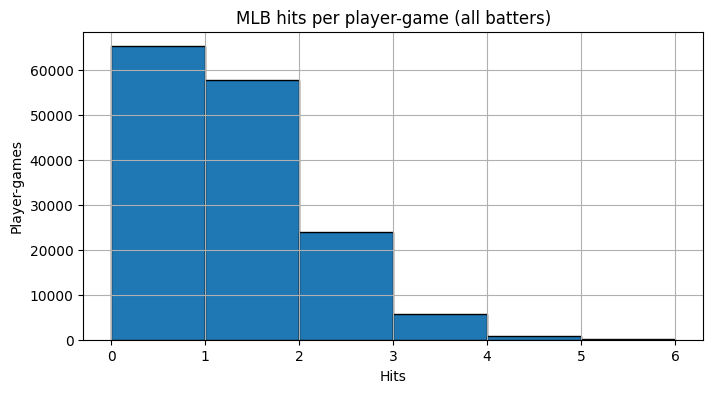

In [4]:
df = q("""
SELECT (pg.stats->>'hits')::int AS hits
FROM player_games pg
JOIN games g USING (game_id)
WHERE g.sport_code='mlb'
  AND (pg.stats->>'plate_appearances')::int > 0;
""")
print(f"Total player-games: {len(df):,}")
print(df["hits"].describe())
df["hits"].hist(bins=range(0, 7), edgecolor='black', figsize=(8, 4))
plt.title("MLB hits per player-game (all batters)")
plt.xlabel("Hits")
plt.ylabel("Player-games")
plt.show()

In [5]:
df = q("""
SELECT p.full_name,
       COUNT(*) AS games,
       AVG((pg.stats->>'hits')::int) AS avg_hits,
       AVG(CASE WHEN (pg.stats->>'hits')::int >= 2 THEN 1.0 ELSE 0.0 END) AS over_15_rate
FROM player_games pg
JOIN players p USING (player_id)
JOIN games g USING (game_id)
WHERE g.sport_code='mlb'
  AND (pg.stats->>'plate_appearances')::int >= 3
GROUP BY p.full_name
HAVING COUNT(*) >= 30
ORDER BY over_15_rate DESC
LIMIT 30;
""")
df

,full_name,games,avg_hits,over_15_rate
0,Luis Arraez,460,1.319565,0.378261
1,Ronald Acuña Jr.,305,1.196721,0.370492
2,Roman Anthony,67,1.119403,0.358209
3,Yandy Díaz,426,1.197183,0.356808
4,Xavier Edwards,236,1.186441,0.347458
5,Bo Bichette,371,1.210243,0.345013
6,Jacob Wilson,147,1.170068,0.340136
7,Daylen Lile,100,1.100000,0.340000
8,Trea Turner,448,1.185268,0.337054
9,Jose Altuve,405,1.160494,0.335802


In [6]:
q("""
SELECT p.full_name, pl.sport_code, pl.stat_type, pl.line_value
FROM prop_lines pl
JOIN players p ON p.player_id=pl.player_id
WHERE pl.sportsbook='prizepicks'
  AND pl.line_variant='standard'
  AND pl.sport_code='mlb'
ORDER BY pl.stat_type, p.full_name
LIMIT 30;
""")

,full_name,sport_code,stat_type,line_value
0,Aaron Civale,mlb,earned_runs_allowed,2.5
1,Aaron Civale,mlb,earned_runs_allowed,3.5
2,Bailey Falter,mlb,earned_runs_allowed,1.5
3,Bailey Falter,mlb,earned_runs_allowed,1.5
4,Bailey Falter,mlb,earned_runs_allowed,1.5
5,Bailey Falter,mlb,earned_runs_allowed,1.5
6,Bailey Falter,mlb,earned_runs_allowed,1.5
7,Braxton Ashcraft,mlb,earned_runs_allowed,0.5
8,Braxton Ashcraft,mlb,earned_runs_allowed,3.5
9,Braxton Ashcraft,mlb,earned_runs_allowed,1.5


In [7]:
df = q("""
WITH player_history AS (
    SELECT p.player_id, p.full_name,
           AVG((pg.stats->>'hits')::int) AS avg_hits,
           AVG(CASE WHEN (pg.stats->>'hits')::int >= 2 THEN 1.0 ELSE 0.0 END) AS hist_over_15,
           COUNT(*) AS sample
    FROM player_games pg
    JOIN players p USING (player_id)
    JOIN games g USING (game_id)
    WHERE g.sport_code='mlb'
      AND (pg.stats->>'plate_appearances')::int >= 3
    GROUP BY p.player_id, p.full_name
    HAVING COUNT(*) >= 30
),
current_lines AS (
    SELECT p.player_id, AVG(pl.line_value) AS pp_line
    FROM prop_lines pl
    JOIN players p ON p.player_id=pl.player_id
    WHERE pl.sportsbook='prizepicks'
      AND pl.line_variant='standard'
      AND pl.stat_type='hits'
      AND pl.sport_code='mlb'
    GROUP BY p.player_id
)
SELECT ph.full_name, ph.avg_hits, ph.hist_over_15, ph.sample, cl.pp_line
FROM player_history ph
JOIN current_lines cl USING (player_id)
ORDER BY cl.pp_line DESC, ph.hist_over_15 DESC
LIMIT 50;
""")
df

,full_name,avg_hits,hist_over_15,sample,pp_line
0,Julio Rodríguez,1.104167,0.320833,480,1.5
1,Josh Naylor,1.066059,0.302961,439,1.5
2,J.P. Crawford,0.921801,0.241706,422,1.5
3,Andrew Benintendi,0.939948,0.227154,383,1.5
4,Victor Caratini,0.907407,0.226852,216,1.5
5,Kyle Karros,0.725490,0.176471,51,1.5
6,José Fermín,0.673469,0.142857,49,1.5
7,Jac Caglianone,0.602941,0.117647,68,1.5
8,Freddie Freeman,1.151020,0.332653,490,1.0
9,Bobby Witt Jr.,1.196356,0.331984,494,1.0


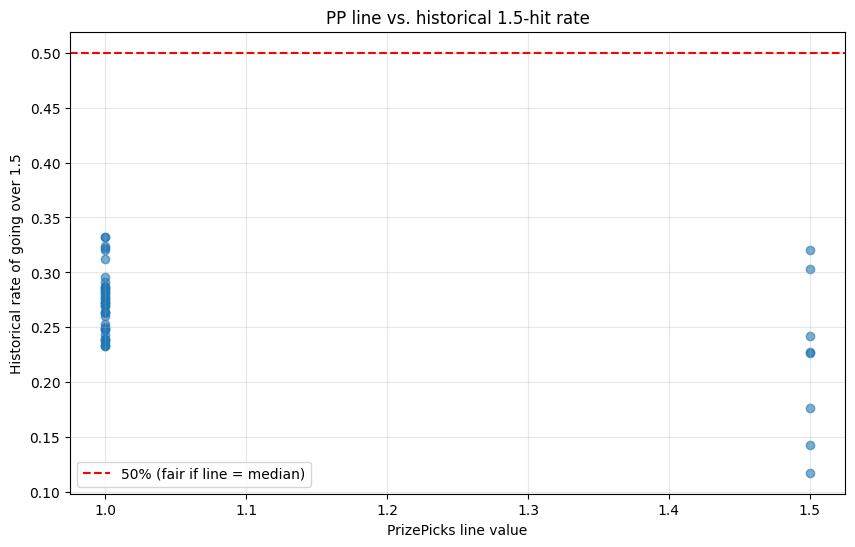

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(df["pp_line"], df["hist_over_15"], alpha=0.6)
plt.axhline(0.5, color='red', linestyle='--', label='50% (fair if line = median)')
plt.xlabel("PrizePicks line value")
plt.ylabel("Historical rate of going over 1.5")
plt.title("PP line vs. historical 1.5-hit rate")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [9]:
df_k = q("""
SELECT p.full_name,
       COUNT(*) AS starts,
       AVG((pg.stats->>'strikeouts_pitcher')::int) AS avg_k,
       AVG((pg.stats->>'outs_recorded')::int / 3.0) AS avg_ip
FROM player_games pg
JOIN players p USING (player_id)
JOIN games g USING (game_id)
WHERE g.sport_code='mlb'
  AND (pg.stats->>'batters_faced')::int >= 15
GROUP BY p.full_name
HAVING COUNT(*) >= 15
ORDER BY avg_k DESC
LIMIT 25;
""")
df_k

,full_name,starts,avg_k,avg_ip
0,Tarik Skubal,81,7.567901,6.164609
1,Garrett Crochet,60,7.533333,5.794444
2,Tyler Glasnow,61,7.491803,5.814208
3,Spencer Strider,61,7.409836,5.661202
4,Chris Sale,72,7.375000,5.819444
5,Blake Snell,66,7.318182,5.666667
6,Shohei Ohtani,33,7.272727,5.747475
7,Zack Wheeler,96,7.208333,6.197917
8,Cole Ragans,58,7.206897,5.660920
9,Paul Skenes,57,7.052632,5.906433


In [10]:
# === Today's logged picks ===
picks = q("""
SELECT p.full_name, pk.stat_type, pl.line_value,
       pk.direction, pk.model_prob, pk.edge,
       pk.actual_value, pk.leg_result,
       pk.picked_at::date AS picked_date
FROM picks pk
JOIN players p USING (player_id)
JOIN prop_lines pl ON pl.line_id = pk.line_id
ORDER BY pk.picked_at DESC;
""")
picks

,full_name,stat_type,line_value,direction,model_prob,edge,actual_value,leg_result,picked_date
0,Sandy Alcantara,strikeouts_pitcher,4.0,over,0.5558,0.0558,NaN,NaN,2026-05-26
1,Josh Naylor,hits,2.5,under,0.9349,0.4349,NaN,NaN,2026-05-26
2,Carlos Cortes,hits,2.5,under,0.9335,0.4335,NaN,NaN,2026-05-26
3,Julio Rodríguez,hits,2.5,under,0.9292,0.4292,NaN,NaN,2026-05-26
4,Victor Caratini,hits,1.5,under,0.7978,0.2978,NaN,NaN,2026-05-26
...,...,...,...,...,...,...,...,...,...
407,Nick Kurtz,hits,1.5,under,0.7646,0.2646,0.0,win,2026-05-25
408,Jake McCarthy,hits,0.5,over,0.6036,0.1036,0.0,loss,2026-05-25
409,Jake McCarthy,hits,1.5,under,0.7632,0.2632,0.0,win,2026-05-25
410,Emmet Sheehan,strikeouts_pitcher,6.0,under,0.8005,0.3005,8.0,loss,2026-05-25


In [11]:
# === Predicted Poisson distributions for tonight's picks ===
import numpy as np
from scipy import stats as scipy_stats

picks_df = q("""
SELECT p.full_name,
       pr.predicted_mean,
       pl.line_value,
       pk.direction
FROM picks pk
JOIN players p USING (player_id)
JOIN prop_lines pl ON pl.line_id = pk.line_id
JOIN predictions pr ON pr.prediction_id = pk.prediction_id
ORDER BY pk.edge DESC;
""")

fig, axes = plt.subplots(1, len(picks_df), figsize=(6 * len(picks_df), 4))
if len(picks_df) == 1:
    axes = [axes]

k_range = np.arange(0, 16)
for ax, (_, row) in zip(axes, picks_df.iterrows()):
    lam = float(row["predicted_mean"])
    line = float(row["line_value"])
    probs = scipy_stats.poisson.pmf(k_range, lam)
    
    colors = ['#999' if k < line else '#4a90e2' for k in k_range]
    ax.bar(k_range, probs, color=colors, edgecolor='black', linewidth=0.5)
    ax.axvline(line, color='red', linestyle='--', linewidth=2, 
               label=f'Line: {line}')
    ax.axvline(lam, color='green', linestyle='-', linewidth=2,
               label=f'Model mean: {lam:.2f}')
    ax.set_xlabel('Strikeouts')
    ax.set_ylabel('Probability')
    ax.set_title(f"{row['full_name']}\nPick: {row['direction'].upper()}")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
# === Total Bases model: what we tried and why we didn't ship ===

# We trained a LightGBM Poisson model on total bases per game using the same
# pipeline as hits. The result:
#
#   - MAE improvement over season-average baseline: 0.04% (effectively zero)
#   - Calibration was actively wrong: at line 0.5 the model said 76% over,
#     actual rate was 60.7%. At line 1.5 it said 53%, actual 43%.
#
# Interpretation:
# 
# 1. Total bases is dominated by player skill (season averages), not matchup.
#    A power hitter's expected TB doesn't move much based on opposing pitcher
#    or recent form because it's largely a function of "do they hit home runs".
#
# 2. Total bases is overdispersed relative to Poisson. A 4-TB game requires
#    either a HR or going 4-for-4 with singles -- two very different events
#    with the same outcome. Poisson assumes mean == variance, which fails
#    badly here.
#
# 3. The calibration table is the model telling us, in advance, that it
#    doesn't work. We're listening.
#
# What this means:
# We did NOT register total_bases_v1 to the model registry. The model file
# and metadata are saved on disk but the pipeline does not generate TB picks.
# Future revisits to consider:
#   - Negative Binomial regression to handle overdispersion
#   - Zero-inflated model (lots of 0-TB outings)  
#   - Mixture model: separate sub-models for HR vs singles+doubles
#   - Different features: pull ball-park HR factor, exit velocity if available
#
# This is the kind of project decision worth making: better to skip a model
# than ship a polluted paper-tracking dataset that confuses the audit later.

print("TB model: trained, evaluated, NOT shipped. See note above.")

TB model: trained, evaluated, NOT shipped. See note above.


In [13]:
# === RBI model: also didn't work, here's why ===

# Trained RBI model with same pipeline as hits.
#
#   - MAE improvement: -2.33% (model is WORSE than baseline)
#   - Calibration: systematically overconfident on OVERs.
#     At line 0.5: model says 52% over, actual rate 39%.
#
# Why RBI is structurally different from hits:
# 
# RBI is fundamentally a team-state stat. To get an RBI you need runners
# on base in front of you. None of our features know about:
#   - Where in the lineup the batter hits (cleanup gets more RBI chances
#     than leadoff)
#   - Team OBP / RISP rate (how often the lineup actually has runners
#     in scoring position)
#   - Bullpen quality vs starter quality
#   - Game script (blowouts shut down RBI chances late)
#
# Top feature was season_avg_home_runs, because HRs are the one RBI source
# that's purely individual-driven. Everything else requires runners.
#
# Pattern from today: 
#   - Hits: WORKS (individual, low variance, matchup-driven) -> 83% UNDER
#   - Strikeouts pitcher: WORKS (same properties)
#   - Total bases: FAILS (overdispersed, dominated by HR variance)
#   - RBI: FAILS (team-context dependent, not individual)
#
# The Poisson + rolling features approach works for stats that are
# (a) individual, (b) low-variance, (c) matchup-driven.
# Violates any of those -> need different modeling approach.

print("RBI model: trained, evaluated, NOT shipped.")

RBI model: trained, evaluated, NOT shipped.
